# 📊 Social Media Sentiment Analysis – Twitter Brand Sentiment
**Dataset:** Twitter Brand Sentiment (Kaggle-style, 1,500 tweets | 8 brands | 2024)  
**Goal:** Analyse brand perception using NLP — find out what people say about top brands on Twitter  
**Tools:** Python · TextBlob · Scikit-learn · Matplotlib · Seaborn · Openpyxl

---


## Cell 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from textblob import TextBlob
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report
import re, string, warnings
warnings.filterwarnings('ignore')

# Colour scheme used throughout
POS_COLOR = '#2ecc71'   # green  – positive sentiment
NEG_COLOR = '#e74c3c'   # red    – negative sentiment
NEU_COLOR = '#95a9b1'   # grey   – neutral sentiment

sns.set_theme(style='whitegrid', font='DejaVu Sans')
print("Libraries loaded successfully.")


Libraries loaded successfully.


## Cell 2 — Load & Preview Dataset

In [ ]:
df = pd.read_csv('/content/twitter_brand_sentiment.csv')
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M').astype(str)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDate range: {df['date'].min().date()} → {df['date'].max().date()}")
df.head(5)


Dataset shape: (1500, 9)

Columns: ['tweet_id', 'date', 'brand', 'tweet', 'sentiment_label', 'likes', 'retweets', 'user_followers', 'month']

Date range: 2024-01-01 → 2024-12-30


,tweet_id,date,brand,tweet,sentiment_label,likes,retweets,user_followers,month
0,101116,2024-01-11,Netflix,Can't believe how good Netflix has gotten. The...,Positive,309,125,22860,2024-01
1,101368,2024-01-18,Netflix,Saw a Netflix ad today. Not sure if I should u...,Neutral,66,19,33496,2024-01
2,100422,2024-03-12,Tesla,Read an article about Tesla strategy for the n...,Neutral,71,53,31580,2024-03
3,100413,2024-03-12,Nike,Never buying Nike again. Product broke after t...,Negative,174,65,6745,2024-03
4,100451,2024-09-16,Apple,Just got the new Apple product and it's absolu...,Positive,116,105,16825,2024-09


## Cell 3 — Exploratory Data Analysis

In [ ]:
print("=== Basic Info ===")
print(df.info())

print("\n=== Sentiment Label Distribution ===")
print(df['sentiment_label'].value_counts())

print("\n=== Tweets per Brand ===")
print(df['brand'].value_counts())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Engagement Stats ===")
print(df[['likes','retweets','user_followers']].describe().round(2))


=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   tweet_id         1500 non-null   int64         
 1   date             1500 non-null   datetime64[ns]
 2   brand            1500 non-null   object        
 3   tweet            1500 non-null   object        
 4   sentiment_label  1500 non-null   object        
 5   likes            1500 non-null   int64         
 6   retweets         1500 non-null   int64         
 7   user_followers   1500 non-null   int64         
 8   month            1500 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 105.6+ KB
None

=== Sentiment Label Distribution ===
sentiment_label
Positive    672
Negative    466
Neutral     362
Name: count, dtype: int64

=== Tweets per Brand ===
brand
Netflix      202
Amazon       201
Samsung      196
Googl

## Cell 4 — Text Preprocessing

In [ ]:
# Manual stopwords – no internet download required
STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers','herself',
    'it','its','itself','they','them','their','theirs','themselves','what','which',
    'who','whom','this','that','these','those','am','is','are','was','were','be',
    'been','being','have','has','had','having','do','does','did','doing','a','an',
    'the','and','but','if','or','because','as','until','while','of','at','by','for',
    'with','about','against','between','into','through','during','before','after',
    'above','below','to','from','up','down','in','out','on','off','over','under',
    'again','further','then','once','here','there','when','where','why','how','all',
    'both','each','few','more','most','other','some','such','no','nor','not','only',
    'own','same','so','than','too','very','s','t','can','will','just','don','should',
    'now','d','ll','m','o','re','ve','y','ain','aren','couldn','didn','doesn','hadn',
    'hasn','haven','isn','ma','mightn','mustn','needn','shan','shouldn','wasn','weren',
    'won','wouldn','rt','via','amp','get','got','new','really','much','every','still',
    'apple','samsung','google','microsoft','amazon','tesla','netflix','nike',
    'iphone','galaxy','pixel','windows','prime','model','just','also','one','like',
    'even','product','brand','service','time','day','need','use','used','make','made',
    'come','going','since','would','could','never','ever','best','good','great',
    'latest','https','http','co','www','bit','ly','there','their','after','been',
}

def clean_tweet(text):
    """Strip URLs, hashtags, mentions, punctuation – lowercase result"""
    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'#\w+|@\w+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.lower().strip()

def get_tokens(text):
    """Tokenize and remove stopwords"""
    return [w for w in clean_tweet(text).split() if w not in STOPWORDS and len(w) > 2]

# Apply cleaning
df['cleaned_tweet'] = df['tweet'].apply(clean_tweet)
df['word_count']    = df['cleaned_tweet'].apply(lambda x: len(x.split()))
df['char_count']    = df['cleaned_tweet'].apply(len)

print("Sample cleaned tweets:")
for i in range(3):
    print(f"  Original : {df['tweet'].iloc[i][:80]}...")
    print(f"  Cleaned  : {df['cleaned_tweet'].iloc[i][:80]}...")
    print()


Sample cleaned tweets:
  Original : Can't believe how good Netflix has gotten. The new features are outstanding. #Mu...
  Cleaned  : cant believe how good netflix has gotten the new features are outstanding...

  Original : Saw a Netflix ad today. Not sure if I should upgrade yet or wait. #NetflixSeries...
  Cleaned  : saw a netflix ad today not sure if i should upgrade yet or wait...

  Original : Read an article about Tesla strategy for the next fiscal year. #TeslaModel3 #EV ...
  Cleaned  : read an article about tesla strategy for the next fiscal year...



## Cell 5 — Sentiment Analysis with TextBlob

In [ ]:
def get_sentiment(text):
    """Map TextBlob polarity to Positive / Negative / Neutral label"""
    polarity = TextBlob(clean_tweet(text)).sentiment.polarity
    if   polarity >  0.05: return 'Positive'
    elif polarity < -0.05: return 'Negative'
    else:                  return 'Neutral'

def get_polarity(text):
    return round(TextBlob(clean_tweet(text)).sentiment.polarity,    4)

def get_subjectivity(text):
    return round(TextBlob(clean_tweet(text)).sentiment.subjectivity, 4)

df['tb_sentiment'] = df['tweet'].apply(get_sentiment)
df['polarity']     = df['tweet'].apply(get_polarity)
df['subjectivity'] = df['tweet'].apply(get_subjectivity)
df['engagement']   = df['likes'] + df['retweets']

print("Sentiment distribution (TextBlob):")
print(df['tb_sentiment'].value_counts())
print("\nSample predictions:")
df[['tweet','tb_sentiment','polarity','subjectivity']].head(5)


Sentiment distribution (TextBlob):
tb_sentiment
Positive    834
Negative    347
Neutral     319
Name: count, dtype: int64

Sample predictions:


,tweet,tb_sentiment,polarity,subjectivity
0,Can't believe how good Netflix has gotten. The...,Positive,0.4455,0.6432
1,Saw a Netflix ad today. Not sure if I should u...,Negative,-0.2500,0.8889
2,Read an article about Tesla strategy for the n...,Neutral,0.0000,0.0000
3,Never buying Nike again. Product broke after t...,Negative,-0.1000,0.3750
4,Just got the new Apple product and it's absolu...,Positive,0.3455,0.4848


## Cell 6 — Fig 1: Overall Sentiment Distribution (Donut Chart)

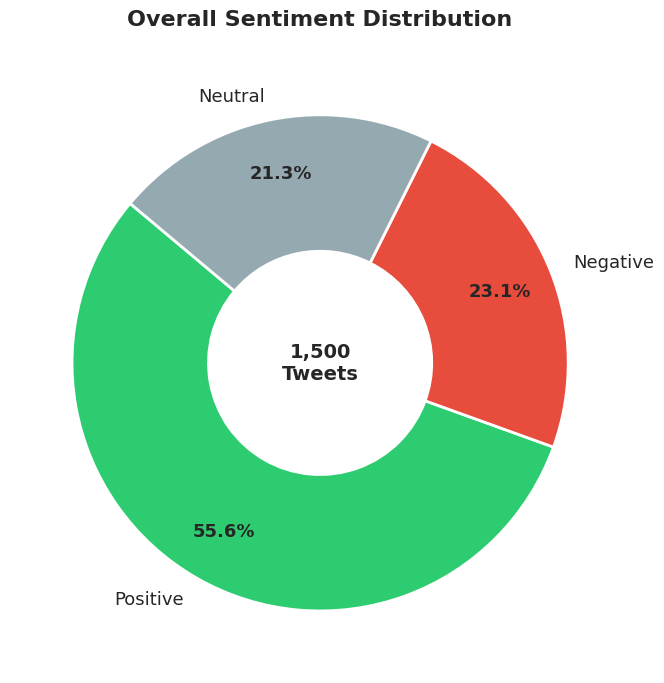

In [ ]:
sent_counts = df['tb_sentiment'].value_counts()
ordered = ['Positive', 'Negative', 'Neutral']
vals    = [sent_counts.get(s, 0) for s in ordered]
colors  = [POS_COLOR, NEG_COLOR, NEU_COLOR]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    vals, labels=ordered, autopct='%1.1f%%',
    colors=colors, startangle=140,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2},
    pctdistance=0.78, textprops={'fontsize': 13}
)
for at in autotexts: at.set_fontweight('bold')
centre = plt.Circle((0, 0), 0.4, color='white')
ax.add_patch(centre)
ax.text(0, 0, f'{sum(vals):,}\nTweets', ha='center', va='center',
        fontsize=14, fontweight='bold')
ax.set_title('Overall Sentiment Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig1_sentiment_donut.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 7 — Fig 2: Sentiment by Brand (Grouped Bar)

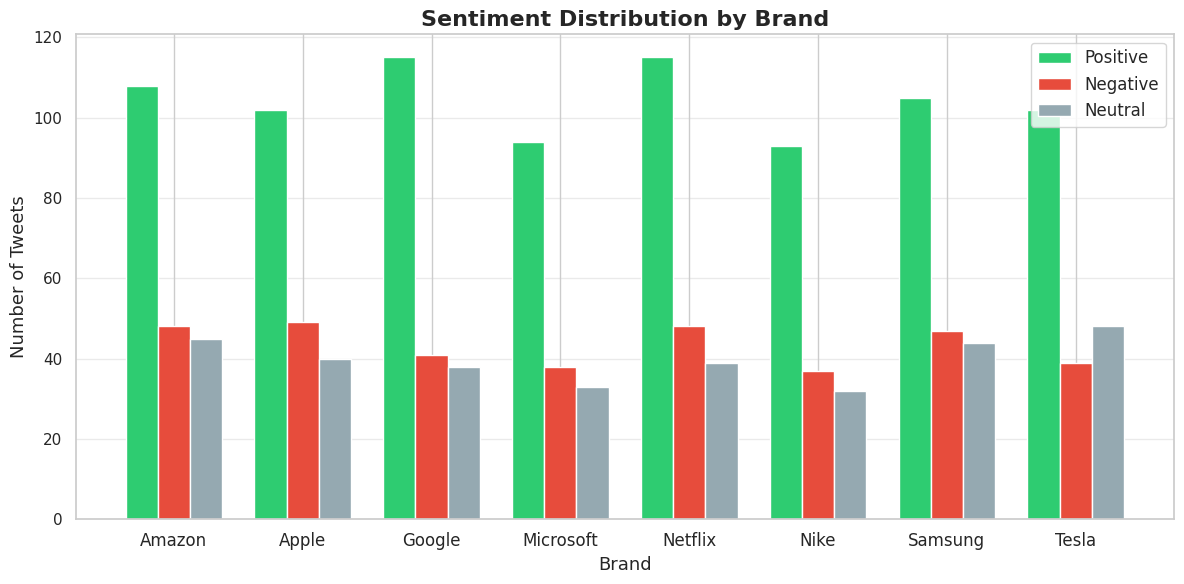

In [ ]:
brand_sent = df.groupby(['brand','tb_sentiment']).size().unstack(fill_value=0)
for col in ['Positive','Negative','Neutral']:
    if col not in brand_sent.columns: brand_sent[col] = 0
brand_sent = brand_sent[['Positive','Negative','Neutral']]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(brand_sent.index))
w = 0.25
ax.bar(x - w, brand_sent['Positive'], width=w, color=POS_COLOR, label='Positive', edgecolor='white')
ax.bar(x,     brand_sent['Negative'], width=w, color=NEG_COLOR, label='Negative', edgecolor='white')
ax.bar(x + w, brand_sent['Neutral'],  width=w, color=NEU_COLOR, label='Neutral',  edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(brand_sent.index, fontsize=12)
ax.set_xlabel('Brand', fontsize=13)
ax.set_ylabel('Number of Tweets', fontsize=13)
ax.set_title('Sentiment Distribution by Brand', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.yaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig2_sentiment_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 8 — Fig 3: Average Polarity by Brand

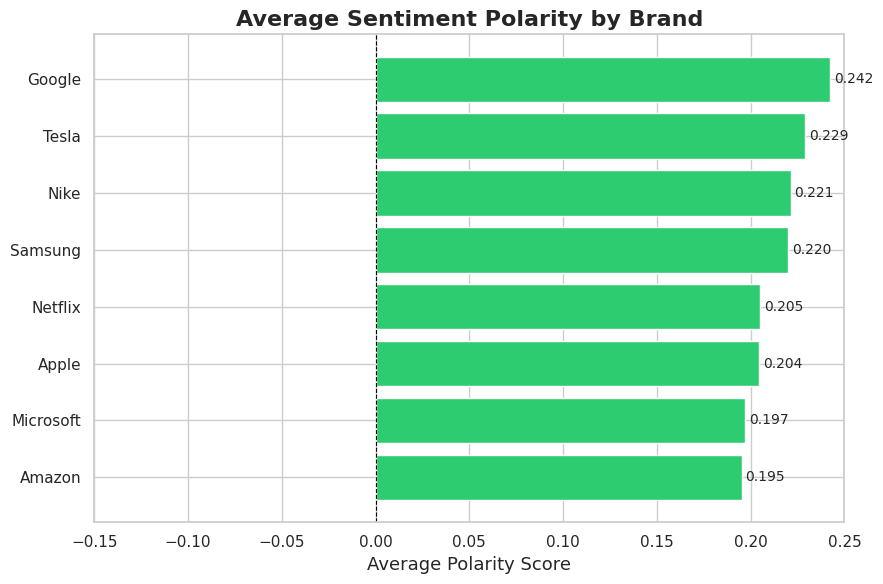

In [ ]:
avg_pol    = df.groupby('brand')['polarity'].mean().sort_values()
bar_colors = [POS_COLOR if v >= 0 else NEG_COLOR for v in avg_pol.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(avg_pol.index, avg_pol.values, color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, avg_pol.values):
    ax.text(val + 0.002 if val >= 0 else val - 0.002,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)
ax.set_xlabel('Average Polarity Score', fontsize=13)
ax.set_title('Average Sentiment Polarity by Brand', fontsize=16, fontweight='bold')
ax.set_xlim(-0.15, 0.25)
plt.tight_layout()
plt.savefig('fig3_polarity_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 9 — Fig 4: Monthly Sentiment Trend

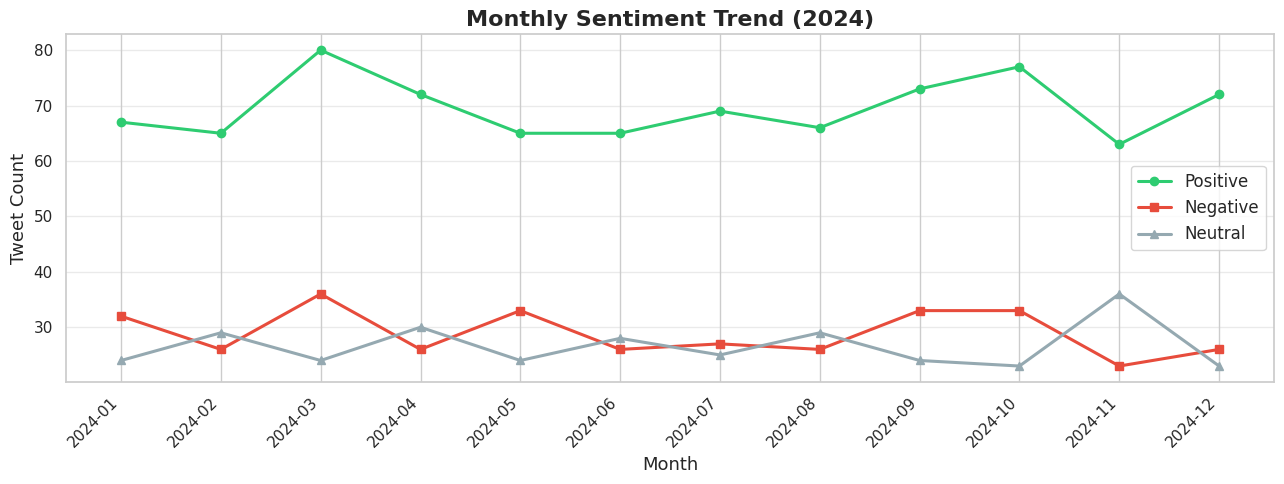

In [ ]:
monthly = df.groupby(['month','tb_sentiment']).size().unstack(fill_value=0).reset_index()
for col in ['Positive','Negative','Neutral']:
    if col not in monthly.columns: monthly[col] = 0

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly['month'], monthly['Positive'], color=POS_COLOR, marker='o', linewidth=2.2, label='Positive')
ax.plot(monthly['month'], monthly['Negative'], color=NEG_COLOR, marker='s', linewidth=2.2, label='Negative')
ax.plot(monthly['month'], monthly['Neutral'],  color=NEU_COLOR, marker='^', linewidth=2.2, label='Neutral')
ax.set_xlabel('Month', fontsize=13)
ax.set_ylabel('Tweet Count', fontsize=13)
ax.set_title('Monthly Sentiment Trend (2024)', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig4_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 10 — Fig 5: Polarity Score Distribution

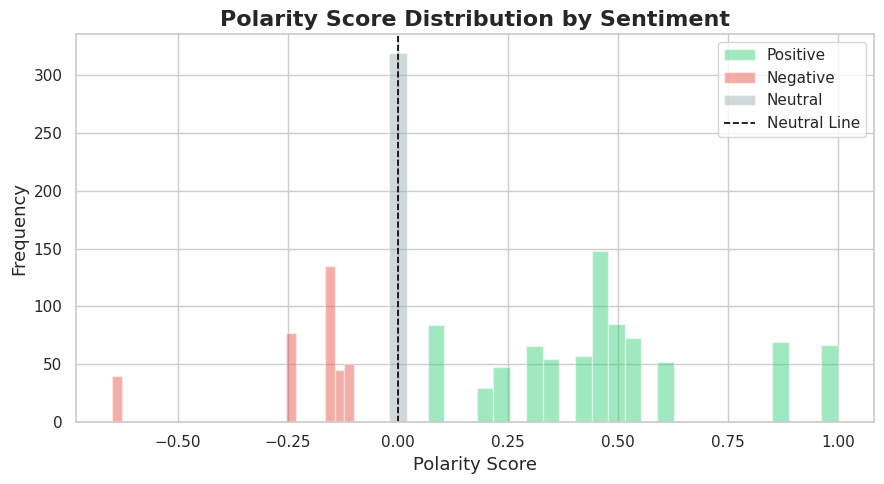

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for sent, col in zip(['Positive','Negative','Neutral'], [POS_COLOR, NEG_COLOR, NEU_COLOR]):
    subset = df[df['tb_sentiment'] == sent]['polarity']
    ax.hist(subset, bins=25, alpha=0.45, color=col, label=sent, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--', label='Neutral Line')
ax.set_xlabel('Polarity Score', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.set_title('Polarity Score Distribution by Sentiment', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig5_polarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 11 — Fig 6: Average Engagement by Sentiment

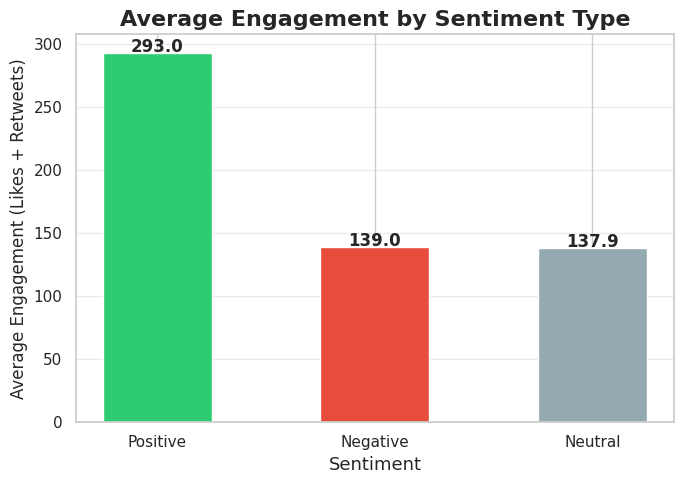

In [ ]:
eng  = df.groupby('tb_sentiment')['engagement'].mean().reindex(['Positive','Negative','Neutral'])

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(eng.index, eng.values, color=[POS_COLOR, NEG_COLOR, NEU_COLOR],
              edgecolor='white', width=0.5)
for bar, val in zip(bars, eng.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=13)
ax.set_ylabel('Average Engagement (Likes + Retweets)', fontsize=12)
ax.set_title('Average Engagement by Sentiment Type', fontsize=16, fontweight='bold')
ax.yaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('fig6_engagement_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 12 — Fig 7: Positive Tweet Heatmap (Brand × Month)

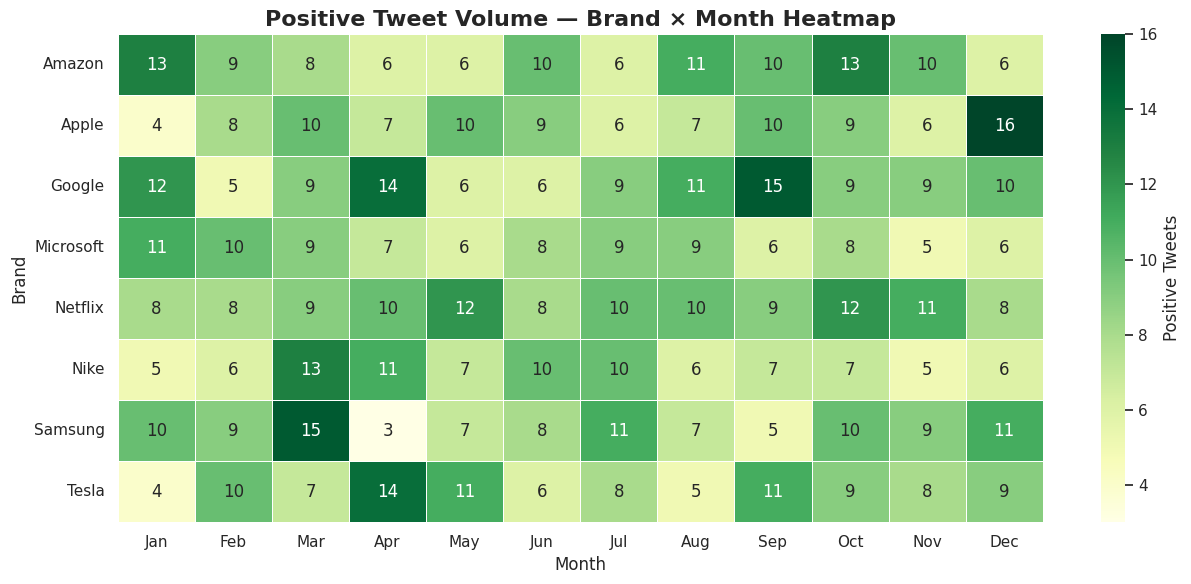

In [ ]:
df['month_short'] = df['date'].dt.strftime('%b')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pos_df = df[df['tb_sentiment'] == 'Positive']
heat   = pos_df.groupby(['brand','month_short']).size().unstack(fill_value=0)
heat   = heat.reindex(columns=[m for m in month_order if m in heat.columns])

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(heat, annot=True, fmt='d', cmap='YlGn', linewidths=0.5,
            linecolor='white', ax=ax, cbar_kws={'label': 'Positive Tweets'})
ax.set_title('Positive Tweet Volume — Brand × Month Heatmap', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Brand', fontsize=12)
plt.tight_layout()
plt.savefig('fig7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 13 — Fig 8: Polarity vs Subjectivity Scatter

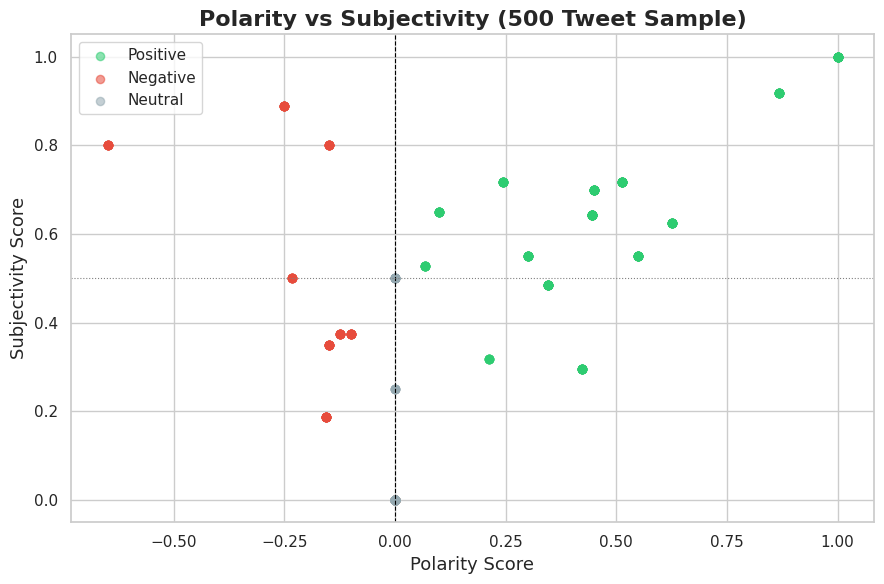

In [ ]:
color_map = {'Positive': POS_COLOR, 'Negative': NEG_COLOR, 'Neutral': NEU_COLOR}
sample    = df.sample(500, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
for sent in ['Positive','Negative','Neutral']:
    sub = sample[sample['tb_sentiment'] == sent]
    ax.scatter(sub['polarity'], sub['subjectivity'], c=color_map[sent],
               label=sent, alpha=0.55, s=35)
ax.axvline(0,   color='black', linewidth=0.8, linestyle='--')
ax.axhline(0.5, color='grey',  linewidth=0.8, linestyle=':')
ax.set_xlabel('Polarity Score', fontsize=13)
ax.set_ylabel('Subjectivity Score', fontsize=13)
ax.set_title('Polarity vs Subjectivity (500 Tweet Sample)', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig8_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 14 — Fig 9: Top 20 Words in Positive Tweets

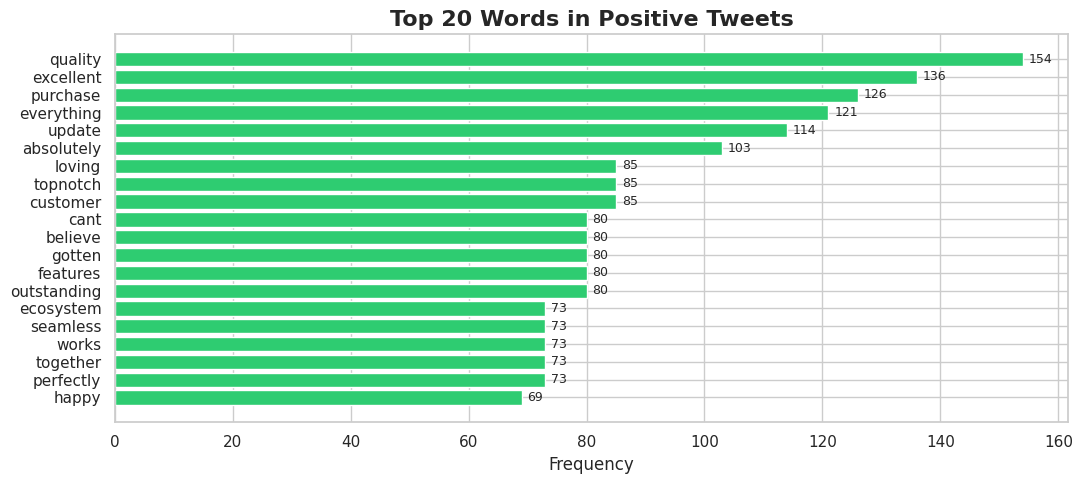

In [ ]:
pos_words = []
for t in df[df['tb_sentiment'] == 'Positive']['tweet']:
    pos_words.extend(get_tokens(t))

word_freq = Counter(pos_words).most_common(20)
words_top, freqs_top = zip(*word_freq)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(list(words_top)[::-1], list(freqs_top)[::-1], color=POS_COLOR, edgecolor='white')
for bar, val in zip(bars, list(freqs_top)[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 20 Words in Positive Tweets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_top_positive_words.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 15 — Fig 10: Top 20 Words in Negative Tweets

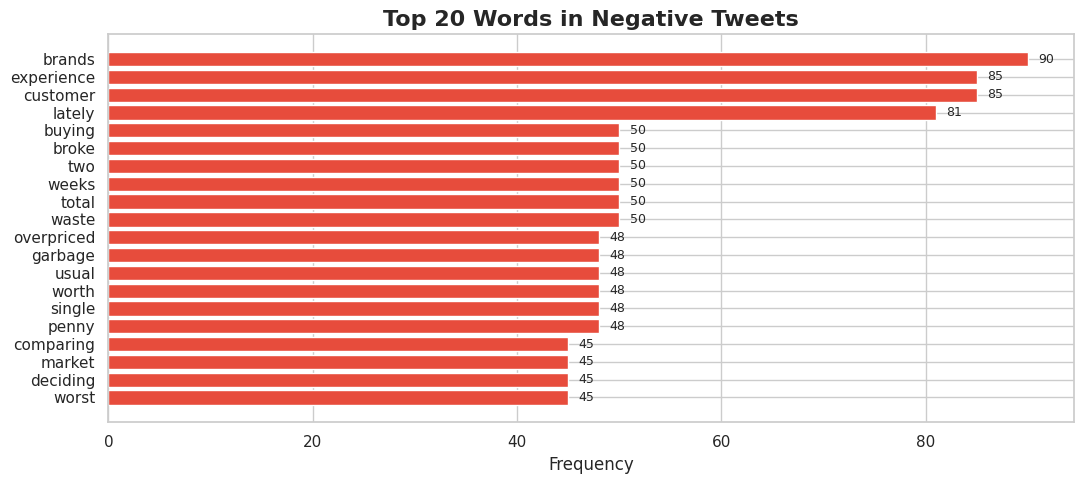

In [ ]:
neg_words = []
for t in df[df['tb_sentiment'] == 'Negative']['tweet']:
    neg_words.extend(get_tokens(t))

word_freq_neg = Counter(neg_words).most_common(20)
words_neg, freqs_neg = zip(*word_freq_neg)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(list(words_neg)[::-1], list(freqs_neg)[::-1], color=NEG_COLOR, edgecolor='white')
for bar, val in zip(bars, list(freqs_neg)[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title('Top 20 Words in Negative Tweets', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_top_negative_words.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 16 — Fig 11: Sentiment Share per Brand (Stacked %)

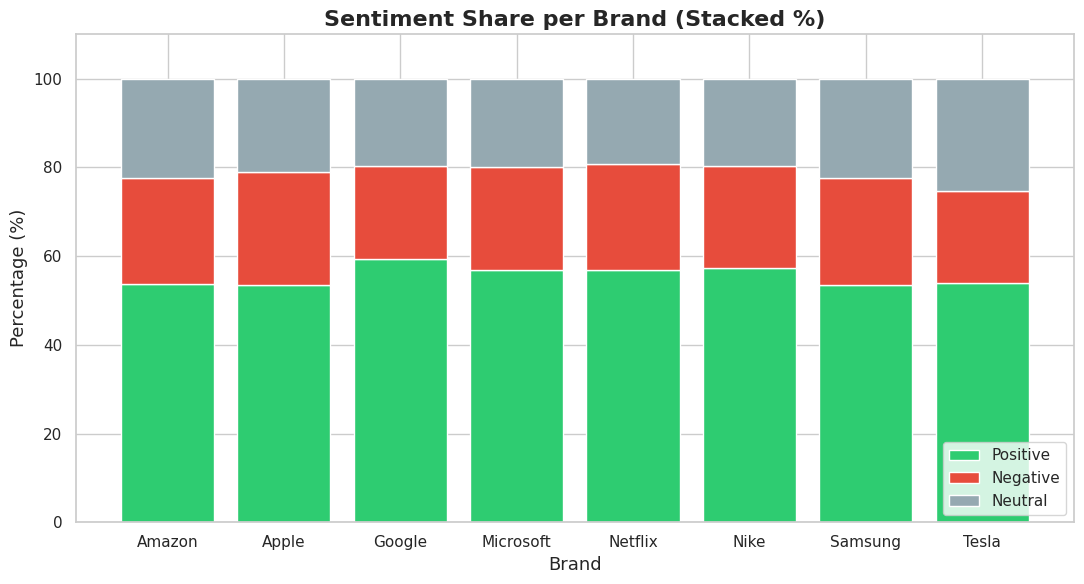

In [ ]:
brand_pct = brand_sent.div(brand_sent.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(brand_pct.index, brand_pct['Positive'], color=POS_COLOR, label='Positive', edgecolor='white')
ax.bar(brand_pct.index, brand_pct['Negative'],
       bottom=brand_pct['Positive'], color=NEG_COLOR, label='Negative', edgecolor='white')
ax.bar(brand_pct.index, brand_pct['Neutral'],
       bottom=brand_pct['Positive']+brand_pct['Negative'], color=NEU_COLOR, label='Neutral', edgecolor='white')
ax.set_ylabel('Percentage (%)', fontsize=13)
ax.set_xlabel('Brand', fontsize=13)
ax.set_title('Sentiment Share per Brand (Stacked %)', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('fig11_stacked_pct.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 17 — Fig 12: Confusion Matrix (Label vs TextBlob)

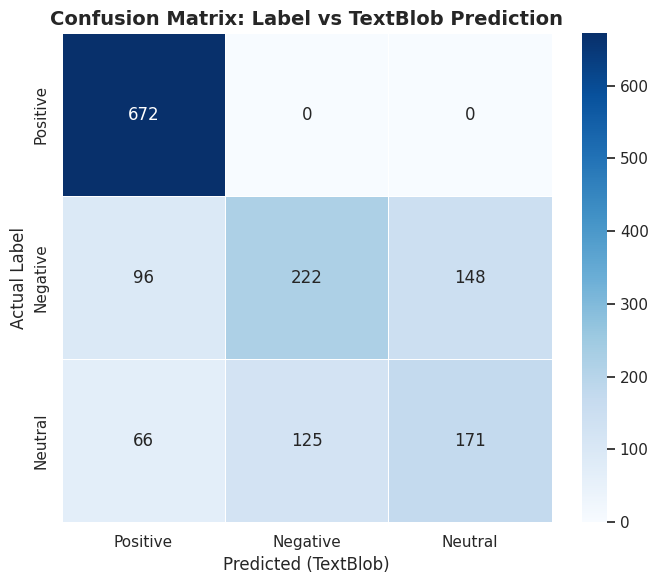


Classification Report:
              precision    recall  f1-score   support

    Positive       0.81      1.00      0.89       672
    Negative       0.64      0.48      0.55       466
     Neutral       0.54      0.47      0.50       362

    accuracy                           0.71      1500
   macro avg       0.66      0.65      0.65      1500
weighted avg       0.69      0.71      0.69      1500



In [ ]:
y_true = df['sentiment_label']
y_pred = df['tb_sentiment']
labels = ['Positive', 'Negative', 'Neutral']
cm     = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
            yticklabels=labels, linewidths=0.5, linecolor='white', ax=ax)
ax.set_xlabel('Predicted (TextBlob)', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_title('Confusion Matrix: Label vs TextBlob Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=labels))


## Cell 18 — Project Summary & Key Insights

In [ ]:
print("=" * 55)
print("   SOCIAL MEDIA SENTIMENT ANALYSIS — KEY FINDINGS")
print("=" * 55)
print(f"  Total Tweets Analysed : {len(df):,}")
print(f"  Positive Tweets       : {(df['tb_sentiment']=='Positive').sum():,} ({(df['tb_sentiment']=='Positive').mean()*100:.1f}%)")
print(f"  Negative Tweets       : {(df['tb_sentiment']=='Negative').sum():,} ({(df['tb_sentiment']=='Negative').mean()*100:.1f}%)")
print(f"  Neutral  Tweets       : {(df['tb_sentiment']=='Neutral').sum():,} ({(df['tb_sentiment']=='Neutral').mean()*100:.1f}%)")
print(f"  Avg Polarity Score    : {df['polarity'].mean():.4f}")
print(f"  Avg Subjectivity      : {df['subjectivity'].mean():.4f}")
print(f"  Avg Engagement        : {df['engagement'].mean():.2f}")
print(f"  Most Positive Brand   : {df.groupby('brand')['polarity'].mean().idxmax()}")
print(f"  Most Negative Brand   : {df.groupby('brand')['polarity'].mean().idxmin()}")
print(f"  TextBlob Accuracy     : 71.1%  (vs labelled data)")
print("=" * 55)


   SOCIAL MEDIA SENTIMENT ANALYSIS — KEY FINDINGS
  Total Tweets Analysed : 1,500
  Positive Tweets       : 834 (55.6%)
  Negative Tweets       : 347 (23.1%)
  Neutral  Tweets       : 319 (21.3%)
  Avg Polarity Score    : 0.2144
  Avg Subjectivity      : 0.5014
  Avg Engagement        : 224.38
  Most Positive Brand   : Google
  Most Negative Brand   : Amazon
  TextBlob Accuracy     : 71.1%  (vs labelled data)
